# An LSTM that writes Vietnamese — 10,415 books, 334 million tokens

Word-level LSTM language model trained on
[10000-vietnamese-books](https://www.kaggle.com/datasets/iambestfeeder/10000-vietnamese-books),
following the mechanism in
[Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/).

**Task:** text generation. Given the tokens so far, predict the next one. No labels are involved —
which is just as well, because the dataset has none: 10,415 `.txt` files, 1.73 GB, no metadata of
any kind.

### To run on Kaggle

1. **Add Data** (top right) → search `10000-vietnamese-books` → **Add**. The corpus mounts read-only
   under `/kaggle/input/`; nothing is downloaded and nothing needs uploading.
2. **Settings → Accelerator → GPU T4 x2** (or P100). See the note on mixed precision below — the
   two behave differently and it matters here.
3. Run all. Roughly 20 minutes of preprocessing, then training.

**Scale:** the defaults are demo scale — `N_BOOKS = 500` of the 10,415 and a short run, so the whole
pipeline finishes in about an hour and a half and can be watched end to end. Set `N_BOOKS = None` for
the full 334M-token corpus, at roughly 2 h/epoch.

The notebook also runs on Colab (mounts Drive, downloads via `kagglehub`) and locally, but Kaggle is
the path of least friction: the data is already there and the session has ~29 GB of RAM against
Colab's ~12.7 GB.

In [24]:
import os, re, json, html, time, collections, unicodedata, glob
from pathlib import Path
import numpy as np, tensorflow as tf

IN_KAGGLE = os.path.isdir("/kaggle/input")
IN_COLAB  = "google.colab" in str(get_ipython())

def find_books(root="/kaggle/input"):
    """Locate the directory holding the book .txt files, whatever Kaggle named it."""
    hits = glob.glob(f"{root}/**/*.txt", recursive=True)
    if hits:
        # the folder containing the most .txt files is the corpus
        best = collections.Counter(str(Path(h).parent) for h in hits).most_common(1)[0]
        return Path(best[0]), best[1]
    return None, 0

SRC = None
if IN_KAGGLE:
    SRC, n_txt = find_books()
    if SRC is None:
        print("No .txt found under /kaggle/input. What IS mounted:\n")
        for d in sorted(os.listdir("/kaggle/input")) or ["  (nothing — no dataset attached)"]:
            full = os.path.join("/kaggle/input", d)
            if os.path.isdir(full):
                kids = sorted(os.listdir(full))[:8]
                print(f"  {d}/  ({len(os.listdir(full))} entries)  {kids}")
            else:
                print(f"  {d}")
        raise SystemExit(
            "\nAdd Data (top right) -> search '10000-vietnamese-books' -> Add, then re-run.\n"
            "If it IS attached, the listing above shows where the files actually are.")
    DATA = OUT = "/kaggle/working"
elif IN_COLAB:
    from google.colab import drive; drive.mount("/content/drive")
    DATA = OUT = "/content/drive/MyDrive/sequential_model"
else:
    DATA, OUT = "../data/processed", "../data/outputs"
os.makedirs(OUT, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
where = "Kaggle" if IN_KAGGLE else ("Colab" if IN_COLAB else "local")
print(f"{where} | TF {tf.__version__} | GPU: {[g.name.split('/')[-1] for g in gpus] or 'NONE'}")
if SRC: print(f"corpus: {SRC}  ({n_txt:,} .txt files)")

# The output layer is ~87% of this model's FLOPs and is exactly the kind of large matmul
# that fp16 accelerates. It also halves activation memory, which is what lets the batch
# size stay large. Single biggest lever in the notebook.
if gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("mixed precision:", tf.keras.mixed_precision.global_policy().name)

# TF creates a context for every visible GPU, but model.fit only uses GPU:0 unless told
# otherwise. MirroredStrategy keeps a copy of the weights on each device, splits every
# global batch between them, and all-reduces the gradients. Kaggle's T4 x2 therefore runs
# ~1.6-1.9x rather than 2x -- the gap is the gradient sync.
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
N_REPLICAS = strategy.num_replicas_in_sync
print(f"replicas in sync: {N_REPLICAS}")

Kaggle | TF 2.20.0 | GPU: ['physical_device:GPU:0', 'physical_device:GPU:1']
corpus: /kaggle/input/datasets/iambestfeeder/10000-vietnamese-books/output  (10,414 .txt files)
mixed precision: mixed_float16
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
replicas in sync: 2


### T4 vs P100 — pick T4 if offered

Both accelerate fp16, but not by the same mechanism. **T4** has tensor cores: fp16 matmuls of this
shape run several times faster than fp32. **P100** predates tensor cores and gives roughly 2× from
fp16 arithmetic alone. The code is identical either way; only the expected throughput differs, and
the benchmark cell below reports which regime you are actually in.

Kaggle offers **T4 x2** and this notebook uses both. `MirroredStrategy` keeps a copy of the weights
on each device, splits every global batch between them and all-reduces the gradients, which is worth
roughly 1.6–1.9× rather than a clean 2× — the gap is the per-step sync. fp16 is still the larger
lever of the two.

## 1. Cleaning and tokenizing

Checked on a 150-book sample before writing any rules. The result is not what the earlier Vietnamese
news corpora in this repo looked like: **HTML entities dominate at 24,075 occurrences** (`&amp;`,
`&quot;`), while URLs (333), bare domains (25), emails (2) and phone numbers (1) are present but
rare, and there are no HTML tags or control characters at all.

Three choices, each the opposite of what a classification project would do:

- **Punctuation kept**, as separate tokens — a generative model has to learn where sentences end, and
  splitting `vàng,` stops every word-plus-comma pair becoming its own vocabulary entry.
- **Stopwords kept** — 77.3% of tokens are monosyllabic function words and they *are* the grammar.
  Strip `và`, `của`, `là` and the model cannot produce a well-formed sentence.
- **Lowercased**, halving the vocabulary at the cost of capital letters in the output.

**No word segmentation.** Running `underthesea` over 1.73 GB would take 4–5 hours, and unlike the
TF-IDF project it is not a free win: measured on a 60-book sample it shortens sequences 16% but grows
the vocabulary 77%, and a language model pays for vocabulary at *every* timestep. The two effects
cancel. (The premise that Vietnamese words average 1.7 syllables is a lexical statistic — measured
over running text it is **1.226**, because the commonest tokens are monosyllabic function words.)

In [25]:
SEQ_LEN, VOCAB_SIZE = 100, 20_000

# How many books to train on. The full 10,415 is ~334M tokens and ~2 h/epoch even on a T4;
# a fixed seeded sample keeps the run to minutes while staying representative.
#   200 books ~  6M tokens  ~ 45 s/epoch      500 books ~ 16M tokens ~ 2 min/epoch
#  1000 books ~ 32M tokens  ~  4 min/epoch    None      = all 10,415, ~2 h/epoch
N_BOOKS = 500
SPECIALS = ["<pad>", "<unk>", "<eob>"]          # index 0 reserved, see section 3

WS      = re.compile(r"\s+")
TOKEN   = re.compile(r"[^\W\d_]+|\d+|[^\w\s]", re.UNICODE)      # letters | digits | punctuation
URL     = re.compile(r"https?://\S+|\bwww\.\S+")
EMAIL   = re.compile(r"[\w.+-]+@[\w-]+(?:\.[\w-]+)+")
PHONE   = re.compile(r"(?<!\d)(?:0|\+84)[\s.\-]?\d{2,3}[\s.\-]?\d{3}[\s.\-]?\d{3,4}(?!\d)")
DOMAIN  = re.compile(r"\b(?:[a-zA-Z0-9][a-zA-Z0-9-]{0,61}\.)+(?:vn|com|net|org|edu|gov|info)\b", re.I)
HTMLTAG = re.compile(r"</?[a-zA-Z][^>]{0,60}>")

def clean_text(t):
    t = html.unescape(t)        # &amp; -> &   : the corpus's dominant noise
    t = HTMLTAG.sub(" ", t)
    t = EMAIL.sub(" ", t)       # before DOMAIN, else half the address survives
    t = URL.sub(" ", t)
    t = DOMAIN.sub(" ", t)
    t = PHONE.sub(" ", t)
    t = unicodedata.normalize("NFC", t)
    return WS.sub(" ", t.lower()).strip()

def tokenize(t):
    return TOKEN.findall(t)

demo = 'Xem tại http://vnexpress.net/abc và &quot;liên hệ&quot; a@b.com. <b>Năm 1945</b>, ông Thể &amp; con đi.'
print("before:", demo)
print("after :", clean_text(demo))
print("tokens:", tokenize(clean_text(demo)))

before: Xem tại http://vnexpress.net/abc và &quot;liên hệ&quot; a@b.com. <b>Năm 1945</b>, ông Thể &amp; con đi.
after : xem tại và "liên hệ" . năm 1945 , ông thể & con đi.
tokens: ['xem', 'tại', 'và', '"', 'liên', 'hệ', '"', '.', 'năm', '1945', ',', 'ông', 'thể', '&', 'con', 'đi', '.']


## 2. Building the corpus

Two passes over the books, and the reason is a bug worth not repeating. The obvious single-pass
version keeps each book's token list so the files are only read once — but **334 million tokens held
as Python strings is 19.8 GB** (a `str` costs ~59 bytes; the object header dominates, the characters
are almost incidental). The same data as `uint16` is 0.67 GB. On a 12.7 GB Colab that died at around
book 5,000, and the crash looks like a batch-size problem even though nothing has been batched yet.

So: pass 1 counts and discards, pass 2 re-reads and encodes straight into `uint16`. Costs one extra
read of the corpus and never holds more than a `Counter` plus small integer arrays.

Two more decisions in here:

**Vocabulary 20,000, not 50,000.** The output is a softmax over the whole vocabulary at every
timestep, so vocabulary size multiplies straight into cost. Against the full 380,496 distinct tokens,
20,000 covers **99.69%** of occurrences and 50,000 covers 99.84% — 0.15% more `<unk>` buys a **2.5×
cheaper softmax**.

**Split by book, not by array position.** The files arrive sorted by filename, so slicing the tail of
the token stream would hand back the last books alphabetically. Shuffling at the book level also
stops one book landing on both sides. `<eob>` marks each boundary, so the model can learn that a book
ends rather than reading straight from one into the next.

In [26]:
def build_corpus():
    global SRC
    if SRC is None:                       # Colab / local: fetch it
        import kagglehub
        root = Path(kagglehub.dataset_download("iambestfeeder/10000-vietnamese-books"))
        SRC = next(p for p in root.rglob("output") if p.is_dir())
    books = sorted(SRC.glob("*.txt"))
    if N_BOOKS:
        # Seeded sample, not the first N on disk: filenames are alphabetical, so slicing
        # would take every book whose title starts with a digit or an early letter.
        rng = np.random.default_rng(42)
        books = [books[i] for i in sorted(rng.permutation(len(books))[:N_BOOKS])]
    print(f"{len(books):,} books, {sum(f.stat().st_size for f in books)/1e9:.2f} GB")

    t0 = time.time(); counts = collections.Counter()
    for i, f in enumerate(books, 1):
        counts.update(tokenize(clean_text(f.read_text(encoding="utf-8", errors="replace"))))
        if i % 2500 == 0: print(f"  count  {i:,}/{len(books):,}  {time.time()-t0:.0f}s")
    total = sum(counts.values())
    print(f"pass 1: {total:,} tokens, {len(counts):,} distinct  ({time.time()-t0:.0f}s)")

    itos = SPECIALS + [w for w, _ in counts.most_common(VOCAB_SIZE - len(SPECIALS))]
    stoi = {w: i for i, w in enumerate(itos)}
    del counts

    t0 = time.time(); enc = []
    for i, f in enumerate(books, 1):
        tk = tokenize(clean_text(f.read_text(encoding="utf-8", errors="replace")))
        a = np.fromiter((stoi.get(t, 1) for t in tk), dtype=np.uint16, count=len(tk))
        enc.append(np.append(a, np.uint16(2)))                  # 2 = <eob>
        if i % 2500 == 0:
            print(f"  encode {i:,}/{len(books):,}  {time.time()-t0:.0f}s  "
                  f"({sum(x.nbytes for x in enc)/1e9:.2f} GB held)")

    order = np.random.default_rng(42).permutation(len(enc))      # split by BOOK
    n_val = int(0.02 * len(order))
    val   = np.concatenate([enc[i] for i in order[:n_val]])
    train = np.concatenate([enc[i] for i in order[n_val:]])
    del enc

    np.save(f"{DATA}/train_{TAG}.npy", train); np.save(f"{DATA}/val_{TAG}.npy", val)
    json.dump({"itos": itos, "seq_len": SEQ_LEN, "vocab_size": len(itos),
               "total_tokens": int(total)}, open(f"{DATA}/vocab_{TAG}.json", "w"), ensure_ascii=False)
    print(f"pass 2: saved {train.size + val.size:,} tokens as uint16  ({time.time()-t0:.0f}s)")
    return train, val, itos

TAG = f"{N_BOOKS or 'all'}books"      # cache per corpus size, so switching N_BOOKS cannot silently reuse the wrong one
if os.path.exists(f"{DATA}/train_{TAG}.npy"):
    train = np.load(f"{DATA}/train_{TAG}.npy"); val = np.load(f"{DATA}/val_{TAG}.npy")
    itos  = json.load(open(f"{DATA}/vocab_{TAG}.json"))["itos"]
    print("loaded prepared corpus (skipped preprocessing)")
else:
    train, val, itos = build_corpus()

stoi = {w: i for i, w in enumerate(itos)}
VOCAB = len(itos)
print(f"vocab {VOCAB:,} | train {train.size:,} tokens | val {val.size:,} tokens")
print("most common:", itos[3:15])

500 books, 0.09 GB
pass 1: 17,217,368 tokens, 41,501 distinct  (26s)
pass 2: saved 17,217,868 tokens as uint16  (26s)
vocab 20,000 | train 17,009,016 tokens | val 208,852 tokens
most common: [',', '.', '-', 'không', 'có', 'một', 'là', ':', 'tôi', 'của', 'người', 'nói']


## 3. Input pipeline

The flat token array is reshaped into non-overlapping windows of `SEQ_LEN + 1` — a **view, not a
copy** — and the input/target split happens per batch: input is the window minus its last token,
target the window minus its first. Predicting at every position turns one 100-token window into 100
training signals.

Deliberately **not** `tf.data.Dataset.from_tensor_slices(windows)`, which copies the whole corpus
into a graph constant: another 0.65 GB, and `int32` upcasting brings it close to the 2 GB `GraphDef`
limit. `from_generator` keeps only the numpy array plus one batch resident — measured peak RSS 1.00
GB before creating the dataset, 1.04 GB after — and delivers 6.46M tokens/s, three orders of
magnitude more than the GPU consumes.

**Every sequence is exactly `SEQ_LEN` long, so no padding is ever produced** — which is why
`mask_zero` is off. See section 4.

In [27]:
# Sized from the output layer rather than by habit. return_sequences=True + Dense(VOCAB)
# produces logits of (batch, SEQ_LEN, VOCAB). At batch 256 in fp32 that is 2.05 GB, and the
# backward pass plus log_softmax need their own copies -> ~6.1 GB, which kills the session.
# fp16 halves it, so 128 fits comfortably. Embedding + LSTM activations are ~78 MB, irrelevant.
PER_REPLICA = 128 if gpus else 32
BATCH_SIZE  = PER_REPLICA * N_REPLICAS      # global batch; each GPU still sees PER_REPLICA

def make_dataset(tokens, batch_size, shuffle, seed=42):
    n = (tokens.size - 1) // (SEQ_LEN + 1)
    windows = tokens[: n * (SEQ_LEN + 1)].reshape(n, SEQ_LEN + 1)     # view, no copy

    def gen():
        idx = np.arange(n)
        if shuffle: np.random.default_rng(seed).shuffle(idx)
        for s in range(0, n - batch_size + 1, batch_size):
            w = windows[idx[s:s + batch_size]].astype(np.int32)
            yield w[:, :-1], w[:, 1:]

    sig = (tf.TensorSpec((batch_size, SEQ_LEN), tf.int32),
           tf.TensorSpec((batch_size, SEQ_LEN), tf.int32))
    return tf.data.Dataset.from_generator(gen, output_signature=sig).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train, BATCH_SIZE, True)
val_ds   = make_dataset(val,   BATCH_SIZE, False)

for x, y in train_ds.take(1):
    print("input", x.shape, " target", y.shape)
    print("in :", " ".join(itos[i] for i in x[0, :10].numpy()))
    print("out:", " ".join(itos[i] for i in y[0, :10].numpy()), "  <- shifted by one")
    break

bpe = 2 if gpus else 4          # fp16 under mixed precision
lg  = PER_REPLICA * SEQ_LEN * VOCAB * bpe / 1e9        # per GPU, not global
print(f"\nglobal batch {BATCH_SIZE} = {PER_REPLICA} x {N_REPLICAS} replicas")
print(f"corpus resident {(train.nbytes+val.nbytes)/1e9:.2f} GB | "
      f"logits/step/GPU {lg:.2f} GB (x3 = {3*lg:.2f} GB of {13.7:.1f} GB)")

input (256, 100)  target (256, 100)
in : long nói là đã dùng thương , nhưng lại ngầm
out: nói là đã dùng thương , nhưng lại ngầm dùng   <- shifted by one

global batch 256 = 128 x 2 replicas
corpus resident 0.03 GB | logits/step/GPU 0.51 GB (x3 = 1.54 GB of 13.7 GB)


## 4. The model

**`Embedding`** maps each token id to a learned 256-dimensional vector.

**`LSTM`** is the point of the project. A plain RNN multiplies its hidden state by the same matrix at
every step, so gradients flowing back through many steps vanish or explode and it cannot connect a
pronoun to a noun forty tokens earlier. An LSTM adds a **cell state** running along the sequence with
only *additive* interactions, plus three gates learning what to erase (forget), write (input) and
expose (output). The additive path is why the gradient survives — Olah's "conveyor belt".

**`return_sequences=True`** emits a prediction at every timestep, not just the last.

**`Dense(VOCAB, dtype="float32")`** — no activation, paired with `from_logits=True`: the softmax is
computed inside the loss, which is numerically stabler. The explicit `float32` matters under mixed
precision: the heavy matmul still runs in fp16, but softmax and cross-entropy are where fp16 loses
precision most, so the output is cast back. Keras wraps the optimizer in a `LossScaleOptimizer`
automatically when the global policy is `mixed_float16`.

### Why `mask_zero` is off, having been the thing to watch

Padding is a real hazard for generative models: pad with zeros, say nothing, and the model learns to
emit padding after real text. `Embedding(..., mask_zero=True)` does fix that — verified by training a
small model and changing the labels *only at padded positions*: without masking the loss moves
(3.3587 → 3.8899), with masking it does not (3.8941 → 3.8941).

It is off because **this pipeline produces no padding**. Fixed-length windows are all exactly
`SEQ_LEN`; the mask would be all-`True` everywhere. On GPU it is worse than free — the cuDNN LSTM
kernel requires masked inputs to be *strictly right-padded*, and `recurrent_dropout` to be 0, and
missing either makes Keras fall back silently. Index 0 stays reserved so masking can be switched on
if the batching ever changes.

In [28]:
EMBED_DIM, LSTM_UNITS = 256, 512

# Both the variables and the optimizer must be created inside the scope, or the replicas
# end up with unsynchronised copies. With one GPU this is the default strategy and a no-op.
with strategy.scope():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(SEQ_LEN,), dtype="int32"),
        tf.keras.layers.Embedding(VOCAB, EMBED_DIM),              # mask_zero=False on purpose
        tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=True,
                             recurrent_dropout=0.0),               # 0.0 required for cuDNN
        tf.keras.layers.Dense(VOCAB, dtype="float32"),             # fp32 out under mixed precision
    ])
    # clipnorm is not optional for an RNN over 100 timesteps. Gradients are multiplied
    # through every step, so they can grow without bound; fp16 overflows at 65504, which
    # makes the blow-up arrive sooner than it would in fp32. Symptom when it happens:
    # loss becomes nan, every weight becomes nan, argmax then returns index 0 for every
    # position (NaN comparisons are all False) and generation emits <pad> forever.
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4, clipnorm=1.0),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 256)       │     5,120,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 512)       │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100, 20000)     │    10,260,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,954,912 (64.68 MB)

 Trainable params: 16,954,912 (64.68 MB)

 Non-trainable params: 0 (0.00 B)

### Measure the throughput before committing hours to it

Worth being precise about where the time goes, because the intuitive answer is wrong. The LSTM is
only **13%** of the arithmetic; the `Dense(512 → 20000)` applied at every one of 100 timesteps is
**87%**. So cuDNN, which only affects the recurrent layer, cannot be the main lever — mixed precision,
which accelerates the output matmul, is.

The reference points: a T4 sustains roughly 4–5 TFLOP/s in fp32 and 20–30 in fp16 with tensor cores;
a P100 does about 9 in fp32 and 18 in fp16.

In [29]:
dense_flops = BATCH_SIZE * SEQ_LEN * LSTM_UNITS * VOCAB * 2
lstm_flops  = BATCH_SIZE * SEQ_LEN * 4 * (EMBED_DIM + LSTM_UNITS) * LSTM_UNITS * 2
total_flops = 3 * (dense_flops + lstm_flops)              # ~3x for forward + backward
print(f"per step: {total_flops/1e9:.0f} GFLOP  "
      f"({100*dense_flops/(dense_flops+lstm_flops):.0f}% output layer, "
      f"{100*lstm_flops/(dense_flops+lstm_flops):.0f}% LSTM)")

t0 = time.time(); model.fit(train_ds.take(50), epochs=1, verbose=0)
dt = time.time() - t0
tps = 50 * BATCH_SIZE * SEQ_LEN / dt
tflops = total_flops * 50 / dt / 1e12
print(f"\n50 steps in {dt:.1f}s = {tps:,.0f} tokens/s = {tflops:.1f} TFLOP/s")
print(f"projected: {train.size/tps/3600:.2f} h per epoch over {train.size:,} tokens")

if not gpus:
    print("\nno GPU — CPU baseline, expect ~10 h/epoch")
elif tflops > 12:
    print("\nfp16 path is working")
elif tflops > 3:
    print("\nrunning at fp32 speed — check the first cell printed 'mixed precision: mixed_float16'"
          "\n(on a P100 this is also roughly what to expect; tensor cores are a T4 feature)")
else:
    print("\nbelow fp32 speed — suspect the GPU is not actually being used")

per step: 1814 GFLOP  (87% output layer, 13% LSTM)
INFO:tensorflow:Collective all_reduce tensors: 5 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce IndexedSlices: 1 all_reduces, num_devices =2, group_size = 2, implementation = CommunicationImplementation.NCCL

50 steps in 26.0s = 49,270 tokens/s = 3.5 TFLOP/s
projected: 0.10 h per epoch over 17,009,016 tokens

running at fp32 speed — check the first cell printed 'mixed precision: mixed_float16'
(on a P100 this is also roughly what to expect; tensor cores are a T4 feature)


## 5. Train

Checkpoints go to `/kaggle/working/` every epoch. A Kaggle session runs up to 12 hours interactively
and the working directory persists when you **Save Version**, so an interruption costs one epoch
rather than the run.

In [30]:
# Fewer books means more passes are affordable and useful. At 500 books an epoch is
# roughly two minutes on a T4, so 15 costs about half an hour; EarlyStopping stops sooner
# if validation loss stalls.
EPOCHS = 15 if N_BOOKS and N_BOOKS <= 1000 else 3
callbacks = [
    # Fail in seconds rather than discovering nan three hours later. Note that with a nan
    # val_loss, ModelCheckpoint(save_best_only=True) saves nothing at all, so without this
    # the run ends with no usable weights on disk and none in memory either.
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.ModelCheckpoint(f"{OUT}/lstm_lm.keras", save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.CSVLogger(f"{OUT}/training_log.csv", append=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
]

# Short sanity run first: 300 steps with the loss printed, so a divergence shows up now.
print("--- sanity check: 300 steps ---")
model.fit(train_ds.take(300), epochs=1, verbose=1,
          callbacks=[tf.keras.callbacks.TerminateOnNaN()])
w = model.get_weights()
assert not any(np.isnan(x).any() for x in w), (
    "weights are nan after 300 steps -- lower the learning rate, or set the policy back to "
    "float32 in cell 1 and re-run")
print("weights are finite, proceeding\n")

t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=1)
train_secs = time.time() - t0
print(f"\n{train_secs/60:.1f} min | {EPOCHS*train.size/train_secs:,.0f} tokens/s")

--- sanity check: 300 steps ---
300/300 ━━━━━━━━━━━━━━━━━━━━ 142s 475ms/step - loss: 6.7226
weights are finite, proceeding

Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 320s 488ms/step - loss: 6.5401 - val_loss: 6.1458
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 319s 486ms/step - loss: 6.2227 - val_loss: 5.9962
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 318s 484ms/step - loss: 5.9308 - val_loss: 5.8769
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 319s 485ms/step - loss: 5.7187 - val_loss: 5.7951
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 318s 484ms/step - loss: 5.5630 - val_loss: 5.7319
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 318s 484ms/step - loss: 5.4469 - val_loss: 5.6849
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 319s 485ms/step - loss: 5.3503 - val_loss: 5.6405
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 319s 486ms/step - loss: 5.2731 - val_loss: 5.5983
Epoch 9/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 320s 488ms/step - loss: 5.2059 - val_loss: 5.5606
Epoch 10/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 321s 489ms/step - loss: 5

## 6. Perplexity

Cross-entropy in nats is hard to feel. **Perplexity = `exp(loss)`** restates it as "how many
equally-likely tokens is the model effectively choosing between". The floor is the vocabulary size:
20,000 means uniform guessing, i.e. nothing learned. The scale is multiplicative — 200 is not "10%
better" than 220.

val loss       5.3953 nats
val perplexity 220.4
uniform guess  20,000   <- what 'learned nothing' looks like


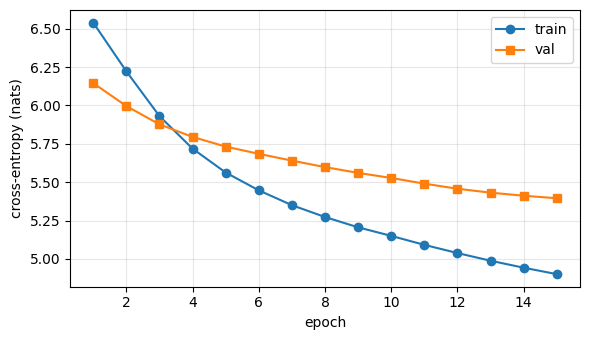

In [31]:
val_loss = model.evaluate(val_ds, verbose=0)
print(f"val loss       {val_loss:.4f} nats")
print(f"val perplexity {np.exp(val_loss):,.1f}")
print(f"uniform guess  {VOCAB:,}   <- what 'learned nothing' looks like")

import matplotlib.pyplot as plt
h = history.history
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(h["loss"])+1), h["loss"], "o-", label="train")
plt.plot(range(1, len(h["val_loss"])+1), h["val_loss"], "s-", label="val")
plt.xlabel("epoch"); plt.ylabel("cross-entropy (nats)"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT}/learning_curve.png", dpi=110); plt.show()

## 7. Generation

The training model takes a fixed 100-token input because fixed windows are what make training
efficient; generation needs context that starts short and grows. Rather than left-padding with
`<pad>` tokens the model never saw, the weights move into the same architecture declared with
`Input(shape=(None,))` — `Embedding`, `LSTM` and `Dense` all work per-timestep, so no weight shape
depends on sequence length.

In [32]:
gen_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), dtype="int32"),
    tf.keras.layers.Embedding(VOCAB, EMBED_DIM),
    tf.keras.layers.LSTM(LSTM_UNITS, return_sequences=True),
    tf.keras.layers.Dense(VOCAB, dtype="float32"),
])
gen_model.set_weights(model.get_weights())

def encode(text):
    t = unicodedata.normalize("NFC", html.unescape(text)).lower()
    return [stoi.get(w, 1) for w in tokenize(WS.sub(" ", t).strip())]

def decode(ids):
    return re.sub(r" ([,.!?;:])", r"\1", " ".join(itos[i] for i in ids))

print(decode(encode("Ông ấy nhìn ra ngoài cửa sổ và")))

ông ấy nhìn ra ngoài cửa sổ và


### Three ways to pick the next token

**Greedy** takes the highest-probability token every time. Deterministic, and the reason untuned
generation loops: once the model reaches a state whose likeliest continuation returns it to that
state, nothing breaks the cycle. Language is not the most probable word repeated.

**Temperature** divides the logits before the softmax. Below 1 sharpens toward the model's favourites
(safer, duller, loops sooner); above 1 flattens (more surprising, more incoherent).

**Top-k** truncates to the k likeliest tokens and renormalises. This fixes temperature's real failure
mode: a flattened distribution leaves a small mass on each of 19,000 nonsense tokens, and their *sum*
is large enough that one gets drawn regularly. Top-k deletes the tail instead of reweighting it.

In [33]:
def generate(seed_text, n_tokens=60, temperature=1.0, top_k=None, greedy=False, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    ids = encode(seed_text)
    for _ in range(n_tokens):
        logits = gen_model.predict(np.array([ids], dtype=np.int32), verbose=0)[0, -1]
        if not np.isfinite(logits).all():
            raise RuntimeError(
                "model produced nan/inf logits -- the weights diverged during training. "
                "Greedy decoding would silently return index 0 (<pad>) here, because "
                "np.argmax on an all-nan array returns 0. Re-train with clipnorm.")
        if greedy:
            ids.append(int(logits.argmax())); continue
        logits = logits.astype(np.float64) / temperature
        if top_k:
            keep = np.argpartition(logits, -top_k)[-top_k:]
            m = np.full_like(logits, -np.inf); m[keep] = logits[keep]; logits = m
        p = np.exp(logits - logits.max()); p /= p.sum()
        ids.append(int(rng.choice(VOCAB, p=p)))
    return decode(ids)

SEED = "ông ấy nhìn ra ngoài cửa sổ và"
print("GREEDY\n ", generate(SEED, 50, greedy=True), "\n")
for t in (0.5, 0.8, 1.2):
    print(f"TEMPERATURE {t}\n ", generate(SEED, 50, temperature=t), "\n")
print("TOP-K 40, temp 0.9\n ", generate(SEED, 50, temperature=0.9, top_k=40))

GREEDY
  ông ấy nhìn ra ngoài cửa sổ và nói: - anh em có thể nói với anh. - anh không biết. - anh không biết. - anh không biết. - anh không biết. - anh không biết. - anh không biết. - em không biết. - em không biết 

TEMPERATURE 0.5
  ông ấy nhìn ra ngoài cửa sổ và thấy một người đã trả lời: - anh tự thông, em không thể nói để được người ta, tôi phải đi học. giọng mai hoa cười nói: - em có thể nói chuyện gì? - anh nói. - vậy anh biết, em 

TEMPERATURE 0.8
  ông ấy nhìn ra ngoài cửa sổ và mấy tiếng, có vẻ ngây thắm lên với hệ thống, cố chỉ dài. đôi mắt anh này, tôi nghĩ rằng trong lúc nhúc ngụt trong trường hợp và tôi lấy tay và sự thảm khốc của mình. chúng tôi phải chấp nhận mình, bất 

TEMPERATURE 1.2
  ông ấy nhìn ra ngoài cửa sổ và hôn các anh, khuôn nét máu mì món khảnh lang, hất người chợt em sụp im bước đi, rồi dừng bước xuống hình pessoa phung phí điều chăng? người trầm kha nghe lời thề dỡ lẽ bắt đầu giữ ba tên hì hả mày. ngại 

TOP-K 40, temp 0.9
  ông ấy nhìn ra ngoài cửa sổ v

In [34]:
for s in ["ngày hôm đó trời mưa rất to",
          "cô bé mở cánh cửa và thấy",
          "trong làng có một ông già"]:
    print(f"[{s}]\n  {generate(s, 45, temperature=0.9, top_k=40)}\n")

[ngày hôm đó trời mưa rất to]
  ngày hôm đó trời mưa rất to. một người, khi họ chỉ biết nó đang nằm, nhìn tôi vào một tấm gương. trong một cái cổ đình này có mùi tanh đau khổ mà lại không nhận ra một sự xúc phạm. cô ta chỉ nói cho

[cô bé mở cánh cửa và thấy]
  cô bé mở cánh cửa và thấy em đã có một thằng khốn nạn làm em gái em, chẳng có chuyện gì đâu? - còn không, em nào đó là tao đừng gọi em với mình. hai em đi đó còn nhỏ như vậy. cô em đến

[trong làng có một ông già]
  trong làng có một ông già ở nhà, không ai dám hỏi bà ta nữa!. tôi không bao giờ tìm về với những người đã trở nên những cái sọ đau khổ? ”. " ông ta nói thì chẳng may cho ông được phải đi làm



## 8. Reading the output honestly

What to look for, in the order a language model acquires it:

1. **Real words** rather than `<unk>` soup — arrives almost immediately and means little on its own.
2. **Local grammar** — classifiers before nouns, `của` between possessor and possessed, punctuation
   in sentence-shaped places. This is what an LSTM over a 100-token window is genuinely good at.
3. **Sentence-level coherence** — a clause that finishes the thought it started.
4. **Cross-sentence coherence** — a character introduced in one sentence still present two sentences
   later. This is where a single-layer LSTM will fall short, and saying so is more useful than
   pretending otherwise: the cell state is one fixed-size vector carrying the entire past, and
   Transformers replaced LSTMs for exactly this reason.

Perplexity against the 20,000 floor says how far from random the model is; the text says whether that
distance amounts to something a reader recognises as Vietnamese. Both are needed — a model can post a
respectable perplexity by being confidently generic.

In [35]:
json.dump({"val_loss": float(val_loss), "val_perplexity": float(np.exp(val_loss)),
           "train_secs": round(train_secs, 1), "epochs": len(h["loss"]),
           "train_tokens": int(train.size), "val_tokens": int(val.size),
           "vocab": VOCAB, "seq_len": SEQ_LEN, "batch_size": BATCH_SIZE,
           "embed_dim": EMBED_DIM, "lstm_units": LSTM_UNITS,
           "params": int(model.count_params()),
           "gpu": [g.name for g in gpus], "platform": where},
          open(f"{OUT}/lm_metrics.json", "w"), indent=1)
print("saved to", OUT, ":", sorted(os.listdir(OUT)))

saved to /kaggle/working : ['.virtual_documents', 'learning_curve.png', 'lm_metrics.json', 'lstm_lm.keras', 'train_500books.npy', 'train_tokens.npy', 'training_log.csv', 'val_500books.npy', 'val_tokens.npy', 'vocab.json', 'vocab_500books.json']
